# 행정동별 복지시설 분석
## 1. 데이터 로드 및 기본 확인

In [23]:
import pandas as pd
import numpy as np

df = pd.read_csv('data.csv')

print('Shape:', df.shape)
print('\n결측치:')
print(df.isnull().sum()[df.isnull().sum() > 0])
df.head()

Shape: (428, 19)

결측치:
총생활인구수           4
청소년인구수           4
청년인구수            4
중장년인구수           4
노인인구수            4
장애인구수            1
노인_의료복지시설수       4
노인_주거복지시설수       4
노인_여가복지시설수       4
노인_일자리지원기관수      4
노인교실수            4
경로당수             4
장애인_생산품판매시설수     4
장애인_의료재활시설수      4
장애인_지역사회재활시설수    4
장애인_직업재활시설수      4
총시설수             4
dtype: int64


,행정동,면적(㎢),총생활인구수,청소년인구수,청년인구수,중장년인구수,노인인구수,장애인구수,노인_의료복지시설수,노인_주거복지시설수,노인_여가복지시설수,노인_일자리지원기관수,노인교실수,경로당수,장애인_생산품판매시설수,장애인_의료재활시설수,장애인_지역사회재활시설수,장애인_직업재활시설수,총시설수
0,사직동,1.23,11181.7368,348.7200,2450.5190,6622.7057,1759.7921,264.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,2.0
1,삼청동,1.49,3955.7911,558.9607,1050.4131,1716.7830,629.6343,102.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,2.0
2,부암동,2.27,10231.3793,744.8383,1946.2463,5387.9186,2152.3761,306.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,3.0
3,평창동,8.87,17295.1528,1169.5429,2883.5715,9332.4074,3909.6310,485.0,8.0,1.0,0.0,0.0,2.0,7.0,0.0,0.0,0.0,0.0,18.0
4,무악동,0.36,5914.8541,434.9992,1137.3527,3108.9253,1233.5769,313.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,5.0


## 2. 전처리 - 결측치 제거

In [24]:
print('결측치 행:')
print(df[df.isnull().any(axis=1)][['행정동', '총생활인구수', '장애인구수']])

df = df.dropna().reset_index(drop=True)
print(f'\n결측치 제거 후 Shape: {df.shape}')

결측치 행:
       행정동      총생활인구수   장애인구수
16   청운효자동  12790.5501   408.0
83    청량리동  16016.4275  1195.0
259   우장산동  30954.5502  1268.0
275     항동         NaN   613.0
325    남현동  21349.3602   573.0
346   반포본동   3149.7709     NaN
361   개포3동         NaN  1117.0
426   상일1동         NaN  1086.0
427   상일2동         NaN   683.0

결측치 제거 후 Shape: (419, 19)


## 3. 파생변수 생성

In [25]:
# 인구밀도 (명/㎢)
df['인구밀도'] = df['총생활인구수'] / df['면적(㎢)']

# 노인 비율 (%)
df['노인비율'] = df['노인인구수'] / df['총생활인구수'] * 100

# 장애인 비율 (%)
df['장애인비율'] = df['장애인구수'] / df['총생활인구수'] * 100

# 노인 시설 수 합계
노인시설_cols = ['노인_의료복지시설수', '노인_주거복지시설수', '노인_여가복지시설수',
               '노인_일자리지원기관수', '노인교실수', '경로당수']
df['노인시설수'] = df[노인시설_cols].sum(axis=1)

# 장애인 시설 수 합계
장애시설_cols = ['장애인_생산품판매시설수', '장애인_의료재활시설수',
               '장애인_지역사회재활시설수', '장애인_직업재활시설수']
df['장애인시설수'] = df[장애시설_cols].sum(axis=1)

# 시설당 노인 수 (시설 0개인 경우 NaN)
df['시설당_노인수'] = df.apply(
    lambda r: r['노인인구수'] / r['노인시설수'] if r['노인시설수'] > 0 else np.nan, axis=1
)

# 시설당 장애인 수 (시설 0개인 경우 NaN)
df['시설당_장애인수'] = df.apply(
    lambda r: r['장애인구수'] / r['장애인시설수'] if r['장애인시설수'] > 0 else np.nan, axis=1
)

print('파생변수 생성 완료')
print('추가된 컬럼:', ['인구밀도', '노인비율', '장애인비율', '노인시설수', '장애인시설수', '시설당_노인수', '시설당_장애인수'])
print()
df[['행정동', '총생활인구수', '인구밀도', '노인인구수', '노인비율',
    '장애인구수', '장애인비율', '노인시설수', '장애인시설수',
    '시설당_노인수', '시설당_장애인수']].head(10)

파생변수 생성 완료
추가된 컬럼: ['인구밀도', '노인비율', '장애인비율', '노인시설수', '장애인시설수', '시설당_노인수', '시설당_장애인수']



,행정동,총생활인구수,인구밀도,노인인구수,노인비율,장애인구수,장애인비율,노인시설수,장애인시설수,시설당_노인수,시설당_장애인수
0,사직동,11181.7368,9090.842927,1759.7921,15.738093,264.0,2.360993,2.0,0.0,879.896050,NaN
1,삼청동,3955.7911,2654.893356,629.6343,15.916773,102.0,2.578498,2.0,0.0,314.817150,NaN
2,부암동,10231.3793,4507.215551,2152.3761,21.037008,306.0,2.990799,3.0,0.0,717.458700,NaN
3,평창동,17295.1528,1949.848117,3909.6310,22.605357,485.0,2.804254,18.0,0.0,217.201722,NaN
4,무악동,5914.8541,16430.150278,1233.5769,20.855576,313.0,5.291762,5.0,0.0,246.715380,NaN
5,교남동,5748.7078,16424.879429,974.1405,16.945382,336.0,5.844792,8.0,0.0,121.767562,NaN
6,가회동,3229.6829,5980.894259,658.0285,20.374400,168.0,5.201749,4.0,0.0,164.507125,NaN
7,종로1.2.3.4가동,28094.7355,11955.206596,3268.2326,11.632900,368.0,1.309854,5.0,0.0,653.646520,NaN
8,종로5.6가동,7972.8141,13288.023500,1258.8330,15.789068,243.0,3.047857,8.0,0.0,157.354125,NaN
9,이화동,28208.9365,36165.303205,3089.8411,10.953412,281.0,0.996138,8.0,0.0,386.230138,NaN


## 4. EDA - 기술통계

In [26]:
eda_cols = ['총생활인구수', '인구밀도', '노인인구수', '노인비율',
            '장애인구수', '장애인비율', '노인시설수', '장애인시설수', '총시설수']
df[eda_cols].describe().round(2)

,총생활인구수,인구밀도,노인인구수,노인비율,장애인구수,장애인비율,노인시설수,장애인시설수,총시설수
count,419.00,419.00,419.00,419.00,419.00,419.00,419.00,419.00,419.00
mean,21159.98,21058.53,3423.44,16.86,908.49,4.76,10.53,0.39,10.92
std,9765.20,11065.26,1501.04,4.03,485.55,2.55,8.12,1.10,8.46
min,2918.18,1097.02,478.91,6.01,39.00,0.58,0.00,0.00,0.00
25%,14249.88,13131.99,2379.63,14.00,550.50,2.99,6.00,0.00,6.00
50%,19716.02,20041.76,3184.75,17.09,808.00,4.45,9.00,0.00,9.00
75%,26741.21,28325.98,4176.88,19.77,1200.00,5.90,13.00,0.00,14.00
max,66576.16,95200.06,11379.84,30.09,3553.00,19.72,89.00,8.00,92.00


## 5. EDA - 주요 변수 분포

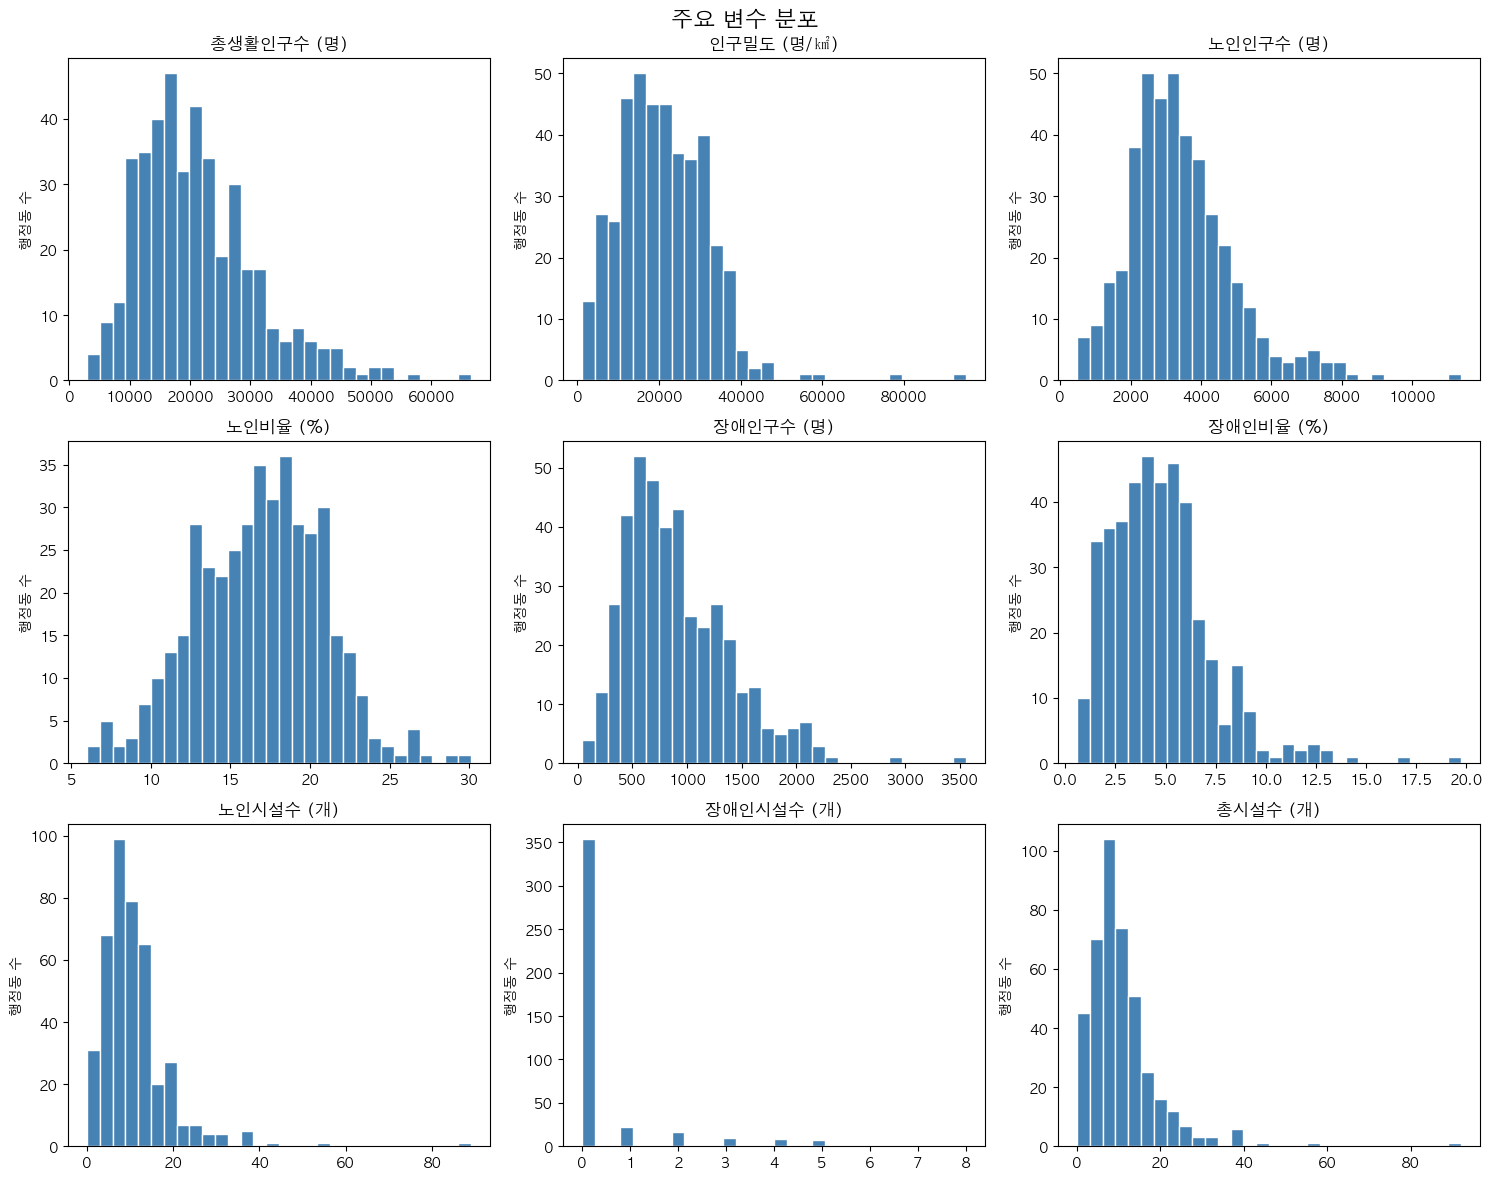

In [27]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('주요 변수 분포', fontsize=16, fontweight='bold')

plot_vars = [
    ('총생활인구수', '총생활인구수 (명)'),
    ('인구밀도',    '인구밀도 (명/㎢)'),
    ('노인인구수',  '노인인구수 (명)'),
    ('노인비율',    '노인비율 (%)'),
    ('장애인구수',  '장애인구수 (명)'),
    ('장애인비율',  '장애인비율 (%)'),
    ('노인시설수',  '노인시설수 (개)'),
    ('장애인시설수','장애인시설수 (개)'),
    ('총시설수',    '총시설수 (개)'),
]

for ax, (col, label) in zip(axes.flatten(), plot_vars):
    ax.hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    ax.set_title(label)
    ax.set_ylabel('행정동 수')

plt.tight_layout()
plt.show()

## 6. EDA - 상관관계 히트맵

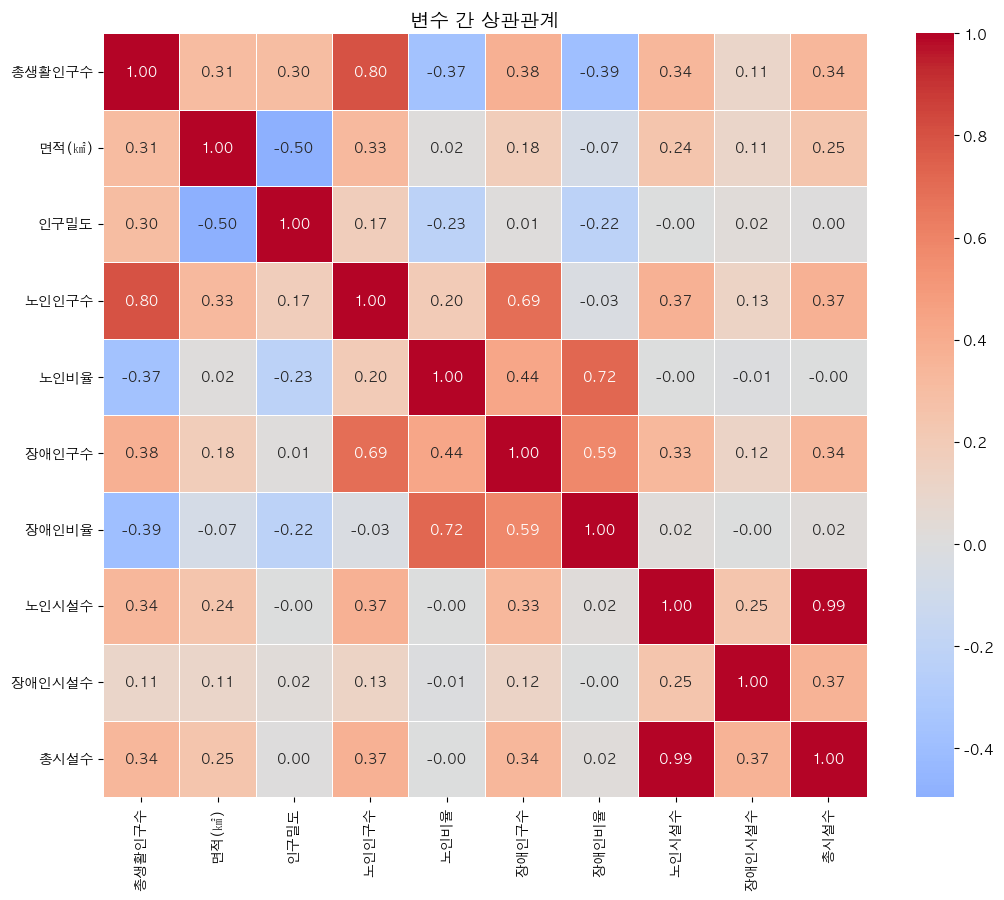

총시설수와의 상관계수 (높은 순):
노인시설수     0.992
노인인구수     0.373
장애인시설수    0.369
총생활인구수    0.340
장애인구수     0.336
면적(㎢)     0.249
장애인비율     0.022
인구밀도      0.003
노인비율     -0.002
Name: 총시설수, dtype: float64


In [28]:
import seaborn as sns

corr_cols = ['총생활인구수', '면적(㎢)', '인구밀도',
             '노인인구수', '노인비율', '장애인구수', '장애인비율',
             '노인시설수', '장애인시설수', '총시설수']

corr = df[corr_cols].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('변수 간 상관관계', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('총시설수와의 상관계수 (높은 순):')
print(corr['총시설수'].drop('총시설수').sort_values(ascending=False).round(3))

## 7. EDA - 상위/하위 행정동 순위

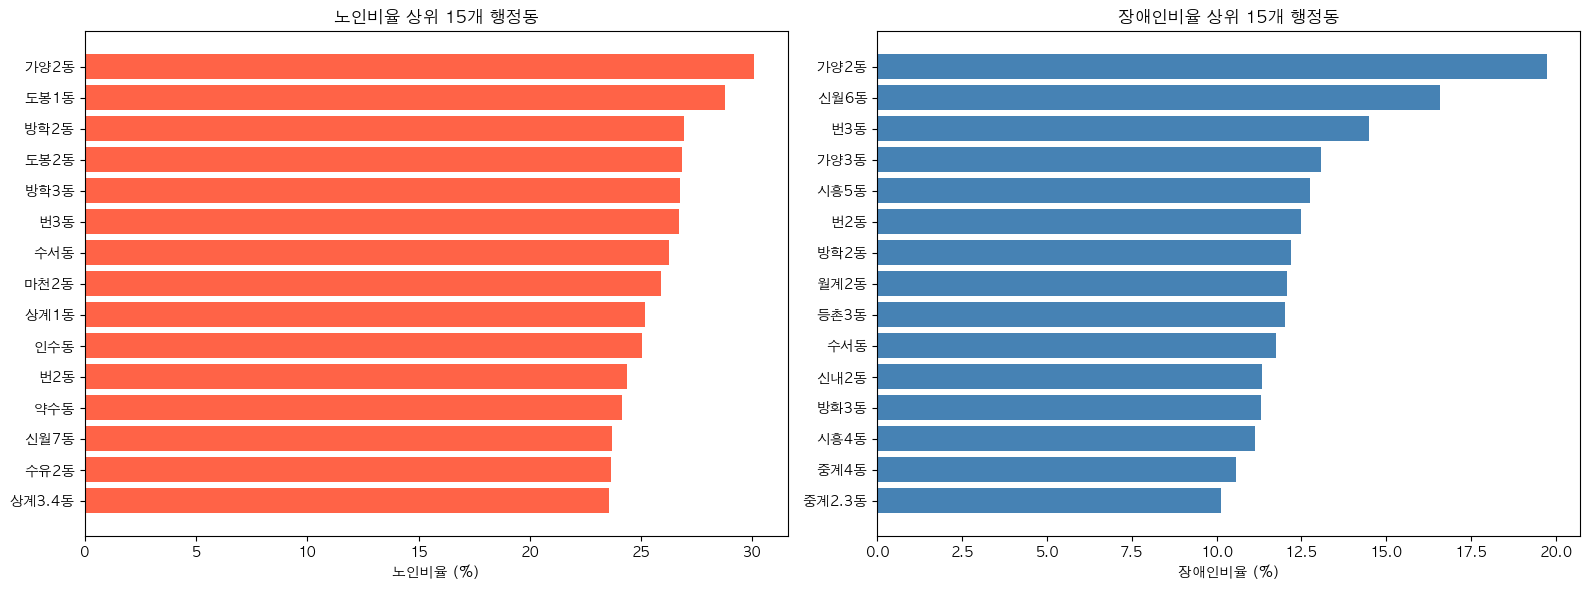

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 노인비율 상위 15개
top_노인 = df.nlargest(15, '노인비율')[['행정동', '노인비율']]
axes[0].barh(top_노인['행정동'][::-1], top_노인['노인비율'][::-1], color='tomato')
axes[0].set_title('노인비율 상위 15개 행정동', fontweight='bold')
axes[0].set_xlabel('노인비율 (%)')

# 장애인비율 상위 15개
top_장애 = df.nlargest(15, '장애인비율')[['행정동', '장애인비율']]
axes[1].barh(top_장애['행정동'][::-1], top_장애['장애인비율'][::-1], color='steelblue')
axes[1].set_title('장애인비율 상위 15개 행정동', fontweight='bold')
axes[1].set_xlabel('장애인비율 (%)')

plt.tight_layout()
plt.show()

## 8. EDA - 복지 공백 지역

In [30]:
# 총시설수 0개인 행정동
no_facility = df[df['총시설수'] == 0][['행정동', '총생활인구수', '노인인구수', '노인비율', '장애인구수', '장애인비율']]
print(f'복지시설 0개 행정동: {len(no_facility)}개')
print()
print(no_facility.sort_values('노인비율', ascending=False).to_string(index=False))

print()
# 노인시설 0개 + 노인비율 높은 곳
취약_노인 = df[(df['노인시설수'] == 0) & (df['노인비율'] > df['노인비율'].median())]
print(f'\n노인시설 없고 노인비율 중앙값 이상인 행정동: {len(취약_노인)}개')
print(취약_노인[['행정동', '노인인구수', '노인비율', '노인시설수']].sort_values('노인비율', ascending=False).to_string(index=False))

복지시설 0개 행정동: 7개

 행정동     총생활인구수     노인인구수      노인비율  장애인구수    장애인비율
 약수동 13059.5144 3152.7871 24.141687  801.0 6.133459
신사2동 15205.9287 3222.7979 21.194351  895.0 5.885862
 청구동 10286.9906 2133.8553 20.743241  582.0 5.657631
 미성동 20605.3007 4079.0516 19.796128 1437.0 6.973934
신사1동 20894.0022 3934.2786 18.829703 1240.0 5.934717
 난향동 10362.2942 1851.1509 17.864296  694.0 6.697359
 조원동 30439.2189 3193.5183 10.491459  751.0 2.467212


노인시설 없고 노인비율 중앙값 이상인 행정동: 6개
 행정동     노인인구수      노인비율  노인시설수
 약수동 3152.7871 24.141687    0.0
신사2동 3222.7979 21.194351    0.0
 청구동 2133.8553 20.743241    0.0
 미성동 4079.0516 19.796128    0.0
신사1동 3934.2786 18.829703    0.0
 난향동 1851.1509 17.864296    0.0


## 9. 랜덤포레스트 - 노인복지시설 변수 중요도

노인 모델 R² (5-fold CV): -0.458 ± 0.746

노인복지시설 변수 중요도:
  노인인구수: 0.3269 (32.7%)
  인구밀도: 0.2215 (22.2%)
  총생활인구수: 0.1687 (16.9%)
  면적(㎢): 0.1573 (15.7%)
  노인비율: 0.1255 (12.5%)


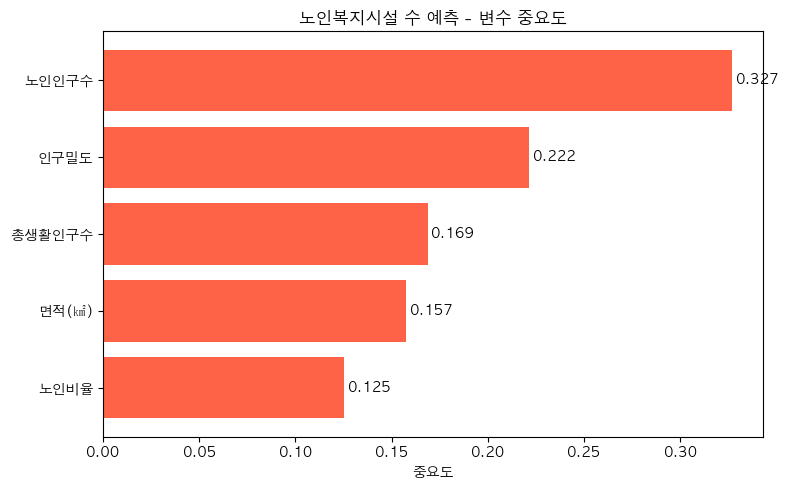

In [31]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

# 노인 관련 독립변수
노인_features = ['노인인구수', '노인비율', '총생활인구수', '면적(㎢)', '인구밀도']
X_노인 = df[노인_features]
y_노인 = df['노인시설수']

rf_노인 = RandomForestRegressor(n_estimators=300, random_state=42)
rf_노인.fit(X_노인, y_노인)

# 교차검증 R²
cv_scores = cross_val_score(rf_노인, X_노인, y_노인, cv=5, scoring='r2')
print(f'노인 모델 R² (5-fold CV): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')
print()

# 변수 중요도
노인_importance = pd.Series(rf_노인.feature_importances_, index=노인_features).sort_values(ascending=False)
print('노인복지시설 변수 중요도:')
for feat, imp in 노인_importance.items():
    print(f'  {feat}: {imp:.4f} ({imp*100:.1f}%)')

# 시각화
plt.figure(figsize=(8, 5))
bars = plt.barh(노인_importance.index[::-1], 노인_importance.values[::-1], color='tomato')
plt.xlabel('중요도')
plt.title('노인복지시설 수 예측 - 변수 중요도', fontweight='bold')
for bar, val in zip(bars, 노인_importance.values[::-1]):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center')
plt.tight_layout()
plt.show()

## 10. 랜덤포레스트 - 장애인복지시설 변수 중요도

장애인 모델 R² (5-fold CV): -0.178 ± 0.219

장애인복지시설 변수 중요도:
  장애인구수: 0.2433 (24.3%)
  인구밀도: 0.2413 (24.1%)
  총생활인구수: 0.1975 (19.7%)
  장애인비율: 0.1689 (16.9%)
  면적(㎢): 0.1490 (14.9%)


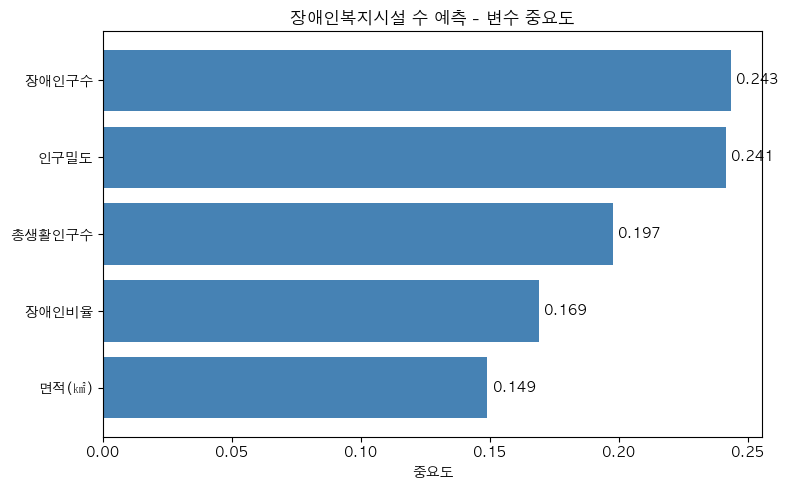

In [32]:
# 장애인 관련 독립변수
장애_features = ['장애인구수', '장애인비율', '총생활인구수', '면적(㎢)', '인구밀도']
X_장애 = df[장애_features]
y_장애 = df['장애인시설수']

rf_장애 = RandomForestRegressor(n_estimators=300, random_state=42)
rf_장애.fit(X_장애, y_장애)

# 교차검증 R²
cv_scores = cross_val_score(rf_장애, X_장애, y_장애, cv=5, scoring='r2')
print(f'장애인 모델 R² (5-fold CV): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')
print()

# 변수 중요도
장애_importance = pd.Series(rf_장애.feature_importances_, index=장애_features).sort_values(ascending=False)
print('장애인복지시설 변수 중요도:')
for feat, imp in 장애_importance.items():
    print(f'  {feat}: {imp:.4f} ({imp*100:.1f}%)')

# 시각화
plt.figure(figsize=(8, 5))
bars = plt.barh(장애_importance.index[::-1], 장애_importance.values[::-1], color='steelblue')
plt.xlabel('중요도')
plt.title('장애인복지시설 수 예측 - 변수 중요도', fontweight='bold')
for bar, val in zip(bars, 장애_importance.values[::-1]):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center')
plt.tight_layout()
plt.show()

## 11. 변수 중요도 비교

변수 중요도 비교표:
        노인복지시설  장애인복지시설
노인비율    0.1255   0.0000
노인인구수   0.3269   0.0000
면적(㎢)   0.1573   0.1490
인구밀도    0.2215   0.2413
장애인구수   0.0000   0.2433
장애인비율   0.0000   0.1689
총생활인구수  0.1687   0.1975


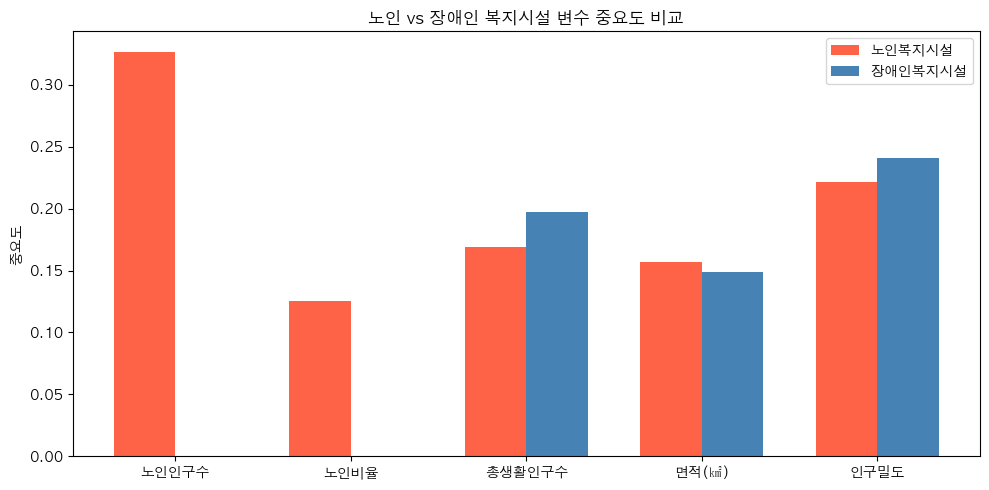

In [33]:
importance_df = pd.DataFrame({
    '노인복지시설': 노인_importance,
    '장애인복지시설': 장애_importance
}).fillna(0)

print('변수 중요도 비교표:')
print(importance_df.round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(노인_features))
w = 0.35
ax.bar(x - w/2, [노인_importance.get(f, 0) for f in 노인_features], w, label='노인복지시설', color='tomato')
ax.bar(x + w/2, [장애_importance.get(f, 0) for f in 노인_features], w, label='장애인복지시설', color='steelblue')
ax.set_xticks(x)
ax.set_xticklabels(노인_features)
ax.set_ylabel('중요도')
ax.set_title('노인 vs 장애인 복지시설 변수 중요도 비교', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 12. 복지 점수 산출 - 변수 재학습 (면적/총인구 제외)

In [34]:
# 면적, 총생활인구수 제외 후 재학습
노인_features2  = ['노인인구수', '노인비율', '인구밀도']
장애_features2  = ['장애인구수', '장애인비율', '인구밀도']

rf_노인2 = RandomForestRegressor(n_estimators=300, random_state=42)
rf_노인2.fit(df[노인_features2], df['노인시설수'])

rf_장애2 = RandomForestRegressor(n_estimators=300, random_state=42)
rf_장애2.fit(df[장애_features2], df['장애인시설수'])

노인_w  = pd.Series(rf_노인2.feature_importances_, index=노인_features2)
장애_w  = pd.Series(rf_장애2.feature_importances_, index=장애_features2)

print('노인복지 변수 중요도(가중치):')
for f, w in 노인_w.sort_values(ascending=False).items():
    print(f'  {f}: {w:.4f} ({w*100:.1f}%)')

print()
print('장애인복지 변수 중요도(가중치):')
for f, w in 장애_w.sort_values(ascending=False).items():
    print(f'  {f}: {w:.4f} ({w*100:.1f}%)')

노인복지 변수 중요도(가중치):
  노인인구수: 0.4356 (43.6%)
  인구밀도: 0.3648 (36.5%)
  노인비율: 0.1996 (20.0%)

장애인복지 변수 중요도(가중치):
  인구밀도: 0.3704 (37.0%)
  장애인구수: 0.3505 (35.1%)
  장애인비율: 0.2791 (27.9%)


## 13. 복지 점수 산출 - 노인/장애인 점수 계산

In [35]:
from sklearn.preprocessing import MinMaxScaler

def calc_score(df, features, weights, score_name):
    """변수 정규화 후 중요도 가중합 → 1~100 스케일링"""
    scaler = MinMaxScaler()
    normalized = scaler.fit_transform(df[features])
    weighted_sum = (normalized * weights.values).sum(axis=1)
    score = (weighted_sum - weighted_sum.min()) / (weighted_sum.max() - weighted_sum.min()) * 99 + 1
    return score

df['노인복지점수']   = calc_score(df, 노인_features2, 노인_w, '노인복지점수')
df['장애인복지점수'] = calc_score(df, 장애_features2, 장애_w, '장애인복지점수')

print('노인복지점수 통계:')
print(df['노인복지점수'].describe().round(2))
print()
print('장애인복지점수 통계:')
print(df['장애인복지점수'].describe().round(2))

노인복지점수 통계:
count    419.00
mean      39.35
std       13.23
min        1.00
25%       31.53
50%       38.18
75%       47.13
max      100.00
Name: 노인복지점수, dtype: float64

장애인복지점수 통계:
count    419.00
mean      32.52
std       13.08
min        1.00
25%       23.43
50%       32.37
75%       41.29
max      100.00
Name: 장애인복지점수, dtype: float64


## 14. 최종 복지 점수 - 데이터 기반 가중치 합산

In [36]:
# 데이터 기반 가중치: 전체 인구 중 노인/장애인 비율로 결정
총_노인   = df['노인인구수'].sum()
총_장애인 = df['장애인구수'].sum()
총합      = 총_노인 + 총_장애인

노인_가중치   = 총_노인 / 총합
장애인_가중치 = 총_장애인 / 총합

print(f'노인 가중치:   {노인_가중치:.4f} ({노인_가중치*100:.1f}%)')
print(f'장애인 가중치: {장애인_가중치:.4f} ({장애인_가중치*100:.1f}%)')

# 최종 점수 합산 후 1~100 재스케일링
raw = df['노인복지점수'] * 노인_가중치 + df['장애인복지점수'] * 장애인_가중치
df['최종복지점수'] = (raw - raw.min()) / (raw.max() - raw.min()) * 99 + 1

print()
print('최종복지점수 통계:')
print(df['최종복지점수'].describe().round(2))

노인 가중치:   0.7903 (79.0%)
장애인 가중치: 0.2097 (21.0%)

최종복지점수 통계:
count    419.00
mean      41.68
std       13.83
min        1.00
25%       33.26
50%       40.95
75%       49.90
max      100.00
Name: 최종복지점수, dtype: float64


## 15. 최종 결과 - 상위/하위 행정동

In [37]:
result = df[['행정동', '노인복지점수', '장애인복지점수', '최종복지점수']].copy()
result = result.sort_values('최종복지점수', ascending=False).reset_index(drop=True)
result.index += 1
result[['노인복지점수','장애인복지점수','최종복지점수']] = result[['노인복지점수','장애인복지점수','최종복지점수']].round(1)

print('=== 복지점수 상위 20개 행정동 ===')
print(result.head(20).to_string())
print()
print('=== 복지점수 하위 20개 행정동 (복지 취약 지역) ===')
print(result.tail(20).to_string())

=== 복지점수 상위 20개 행정동 ===
       행정동  노인복지점수  장애인복지점수  최종복지점수
1       길동   100.0     56.4   100.0
2     화곡8동    90.0     63.7    93.0
3     북아현동    87.9     63.7    91.1
4      대조동    87.5     55.2    88.8
5     등촌3동    69.6    100.0    83.6
6     화곡1동    74.4     63.4    79.3
7      역촌동    73.0     61.0    77.6
8   중계2.3동    65.1     81.6    75.5
9     천호1동    71.2     51.6    73.8
10    천호2동    70.6     45.8    72.0
11     강일동    69.9     43.2    70.7
12    공릉1동    65.9     55.9    70.2
13  상계6.7동    68.1     41.3    68.7
14    상계1동    67.9     40.9    68.4
15     창2동    67.0     43.5    68.3
16     오금동    67.2     40.1    67.6
17    상도1동    65.3     43.4    66.8
18    오류2동    63.7     48.6    66.6
19     송중동    63.6     44.6    65.6
20    신정4동    61.7     50.9    65.4

=== 복지점수 하위 20개 행정동 (복지 취약 지역) ===
       행정동  노인복지점수  장애인복지점수  최종복지점수
400   서빙고동    19.4      9.5    19.0
401    가회동    18.1     12.8    18.6
402   삼성1동    19.1      8.1    18.4
403  이태원2동    17.1     13.8    18.0
404 

## 16. 최종 결과 시각화

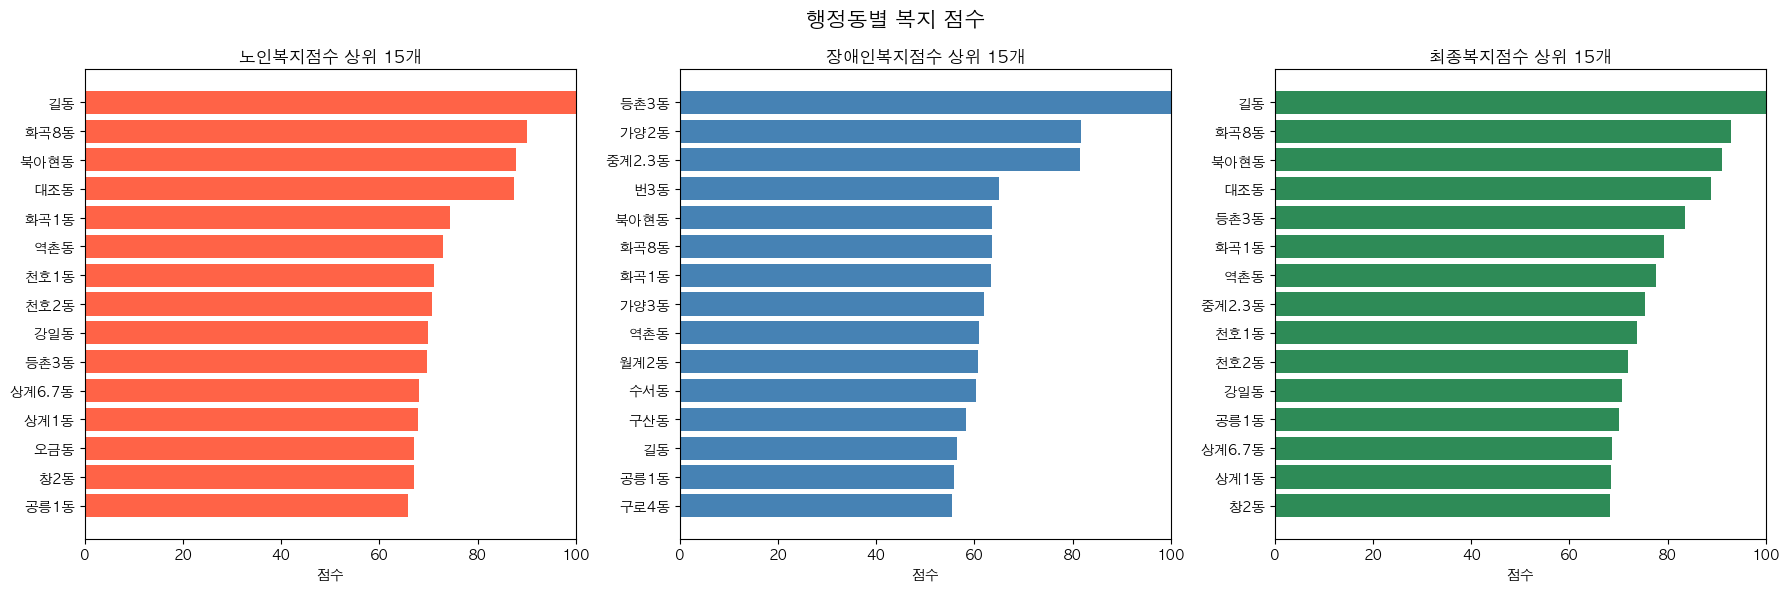

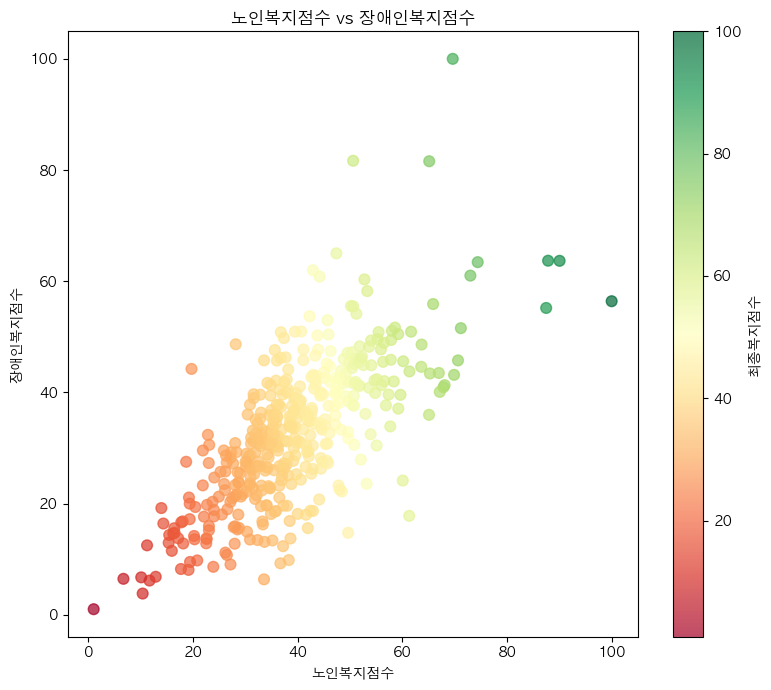

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('행정동별 복지 점수', fontsize=15, fontweight='bold')

score_info = [
    ('노인복지점수',   'tomato',    '노인복지점수'),
    ('장애인복지점수', 'steelblue', '장애인복지점수'),
    ('최종복지점수',   'seagreen',  '최종복지점수'),
]

for ax, (col, color, title) in zip(axes, score_info):
    top15 = df.nlargest(15, col)[['행정동', col]]
    ax.barh(top15['행정동'][::-1], top15[col][::-1], color=color)
    ax.set_title(f'{title} 상위 15개', fontweight='bold')
    ax.set_xlabel('점수')
    ax.set_xlim(0, 100)

plt.tight_layout()
plt.show()

# 노인 vs 장애인 점수 산점도
plt.figure(figsize=(8, 7))
plt.scatter(df['노인복지점수'], df['장애인복지점수'],
            c=df['최종복지점수'], cmap='RdYlGn', s=60, alpha=0.7)
plt.colorbar(label='최종복지점수')
plt.xlabel('노인복지점수')
plt.ylabel('장애인복지점수')
plt.title('노인복지점수 vs 장애인복지점수', fontweight='bold')
plt.tight_layout()
plt.show()